# Task Performance
This data analysis report presents the descriptive and visual analysis as well as the results regarding the participant's task performance from the test session of the Masters' thesis *Recreation for all: Making Nature-Based Accommodations Discoverable for Public Transport Users*. The report includes code blocks, explanations, and the descriptive and visual results. 

Task performance is a multi-dimensional construct consisting of three categories: *Task Success*, *Task Solution Quality*, and *Task Solution Difficulty*. The report focuses on the analysis and results only. Background information and the discussion of results can be accessed from the written thesis document.

*Alischa Thomas - 2026 - Aalto University*

------------------

Project Setup
- Language: Python
- Virtual Environment: Conda. Installed packages come with the Conda environment.
- Juypter Notebook
- Github

---

# Preparation

In [1]:
# Packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch # used to create filled shapes for plots
from matplotlib.lines import Line2D # used to create lines and dots for plots


## Creating and Cleaning Dataset
The following code block imports and prepares the data for further analysis. The original data can found in the xlsx file that is imported in the code from the src folder. The file can be found in the Github repo. Preparation steps include: transposing the data, cleaning up column names, removing data that's not needed.

In [ ]:
# --Import the raw data and create a dataframe--

# --store csv to dataframe--
df_task_performance = pd.read_csv("src/data/raw_data_task_performance_working_file.csv")
df_task_performance

# --Inspect dataframe--
# check data type for cells
df_task_performance.dtypes

# --Transpose dataframe--
df_task_performance_trans = df_task_performance.T
df_task_performance_trans

# --Clean column names--
col_names = ["Task_success", "Min_pref", "Max_pref", "Expected", "Actual", "Diff_expected_actual", "Route_Type", "Cognitive_Process_Type", "Task_start", "Task_end", "Task_conduction_time", "Platform_count", "Mental_load"]
# col_names
df_task_performance_trans.columns = col_names

# --Remove unrequired columns and rows--
df_task_performance_trans = df_task_performance_trans.drop(index=["Variable"])
df_task_performance_trans = df_task_performance_trans.drop(columns=["Task_start", "Task_end"])
df_task_performance_trans
# Calculate deviation in %
# df_task_performance_trans.dtypes

# --Inspect data types per col--
df_types = df_task_performance_trans.map(type)
df_types

# --Convert data types for further analysis--
cols_to_numeric = ["Min_pref", "Max_pref", "Expected", "Actual", "Diff_expected_actual", "Platform_count", "Mental_load"]
df_task_performance_trans[cols_to_numeric] = df_task_performance_trans[cols_to_numeric].apply(pd.to_numeric)
# converts conduction time to datetime in min format
df_task_performance_trans["Task_conduction_time"] = df_task_performance_trans["Task_conduction_time"].apply(pd.to_datetime).dt.time
#df_task_performance_trans["Task conduction time"] = pd.to_datetime(df_task_performance_trans["Task conduction time"]).dt.time
df_task_performance_trans["Task_success"] = df_task_performance_trans["Task_success"].map({"T": True, "F": False}) # converts cells for Task_success to T/F Boolean

df_types = df_task_performance_trans.map(type) # inspect new data types
df_types

# --Show new dataframw with converted types--
df_task_performance_trans
df_task_performance_trans



,Task_success,Min_pref,Max_pref,Expected,Actual,Diff_expected_actual,Route_Type,Cognitive_Process_Type,Task_conduction_time,Platform_count,Mental_load
P1,True,60,180,150,162,12,Street-to-train station,Schematic,00:14:03,2,32
P2,False,60,210,150,207,57,City district-to-address,Search-process-based,00:19:15,7,85
P3,True,60,240,240,271,31,City-to-address,Schematic,00:18:23,4,32
P4,True,90,420,250,296,46,Station-to-station,Schematic,00:22:25,6,25
P5,True,15,120,120,153,33,Station-to-station,Schematic,00:08:57,4,38
P6,True,30,150,80,85,5,City-to-address,Schematic,00:20:50,3,30
P7,True,40,180,180,184,4,City-to-village,Search-process-based,00:19:10,5,57


## Styles

In [22]:
col_orange = '#FFB14E'
col_pink = '#E14A99'
col_violet = '#C67CE8'

fontsize_plot_title = 14
fontsize_subplot_title = 10
fontsize_plot_description = 7
fontsize_axis_labels = 11
fontsize_yaxis_labels_task_difficulty = 7
fontsize_axis_labels_task_difficulty_text_labels = 6
fontsize_axis_labels_task_difficulty_numeric_labels = 5


fontsize_legend = 9
fontsize_legend_task_difficulty = 7



plot_title_position="center"

bar_height_single_bar_plot = 0.2
bar_height_multi_bar_plot = 0.6

vertical_line_width=0.8

grid_alpha=0.8

______________

## Analysis

### <span style="color:#C67CE8">Category 1 - Task Success</span> 
Task success is a binary variable: Success or fail. **6 / 7** participants successfully finished the task in the test session. 

### <span style="color:#C67CE8">Category 2 - Task Solution Quality</span> 
How does the reachability of the trip perform in relation to the participants preferences?

#### Data Preparation
Preparation steps include: extracting relevant data from the original dataframe, calculating average values for additional statistical insight, improving column names and row names. The output is a clean data set which serves as an input for the visual analysis.

In [23]:
#--Create subset of dataframe--
df_task_quality = df_task_performance_trans[["Min_pref", "Max_pref", "Expected", "Actual"]]
# df_task_quality

# Calculate deviation in %
df_task_quality["Diff_Actual_Expected"] = (df_task_quality["Actual"] - df_task_quality["Expected"]) / df_task_quality["Expected"] * 100

# --Add a row with average values--
# calculates average per col
avg = df_task_quality[["Min_pref", "Max_pref", "Expected", "Actual", "Diff_Actual_Expected"]].mean()
df_task_quality = pd.concat([ # concatenate is used to merge two dataframes which we use here to merge the row
    df_task_quality, # names first dataframe for merge
    pd.DataFrame([{ # creates second dataframe for merge from calculated average values. Assing each value to the existing columns in the new row
        "Min_pref": avg.Min_pref ,
        "Expected": avg.Expected,
        "Actual": avg.Actual,
        "Max_pref": avg.Max_pref,
        "Diff_Actual_Expected": avg.Diff_Actual_Expected,
    }])
], ignore_index=False).round(2)

# --renames index values to show participants--
df_task_quality.index = ["P1: Street-to-train station ", "*P2: City district-to-address", "P3: City-to-address", "P4: Train Station-to-train station", "P5: Train station-to-Train station", "P6: City-to-address", "P7: City-to-village", "Mean"]


/var/folders/_9/bgdtlddx52v749qmr4d0z9tr0000gn/T/ipykernel_20901/490946057.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_task_quality["Diff_Actual_Expected"] = (df_task_quality["Actual"] - df_task_quality["Expected"]) / df_task_quality["Expected"] * 100


#### Table: Travel Time to Accommodation (minutes)
The table presents different measures of the preferred, expected, and actual travel time to an accommodation.

1. Participant's general preference for the travel time for a short trip:
- Participant's minimum preferred travel time (assessed through interview data)
- Participant's maximum preferred travel time (assessed through interview data)

2. Travel time related to the specific accommodation selected in the test session:
- Participant's expected travel time** to the accommodation (assessed through interview data)
- Actual travel time to the accommodation, which was validated by the researcher after the test session. Route search parameters: start parameter = participants' start parameters, destination parameter = accommodation address from the Booking.com listing

In [25]:
# Result: dataframe for task quality
df_task_quality_sorted = df_task_quality.sort_values("Diff_Actual_Expected", ascending=False)
df_task_quality_sorted
#df_task_quality

,Min_pref,Max_pref,Expected,Actual,Diff_Actual_Expected
*P2: City district-to-address,60.00,210.00,150.00,207.0,38.00
P5: Train station-to-Train station,15.00,120.00,120.00,153.0,27.50
P4: Train Station-to-train station,90.00,420.00,250.00,296.0,18.40
Mean,50.71,214.29,167.14,194.0,16.18
P3: City-to-address,60.00,240.00,240.00,271.0,12.92
P1: Street-to-train station,60.00,180.00,150.00,162.0,8.00
P6: City-to-address,30.00,150.00,80.00,85.0,6.25
P7: City-to-village,40.00,180.00,180.00,184.0,2.22


#### Plot 1: Travel Time to Accommodation (minutes)
For the visual analysis, the travel-time related data are triangulated in one plot. The visual analysis explores the relation between the participant's general preferences vs. the resulting travel time from the test session. The input for the plot is the cleaned data set from the previous step.

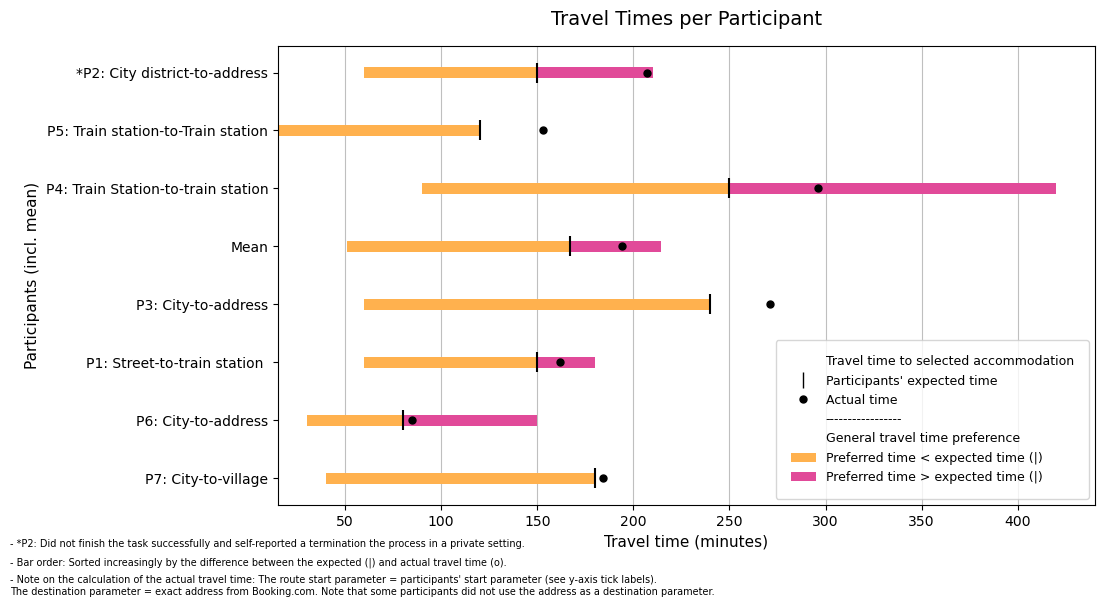

In [26]:
# create figure
plt.figure(figsize=(11, 6))

# y_pos tells matplotlib where to put the bars: on evenly spaced rows
y_pos = np.arange(len(df_task_quality_sorted))

# for each variable for each participant, the bars and markers are created:
for i, row in df_task_quality_sorted.iterrows():
    # Generates first segment of a row
    plt.barh(
        y=i, # y = participants
        width=row["Expected"] - row["Min_pref"], # width of the the first row segment: Expected travel time - minimum preferred travel time
        left=row["Min_pref"], # starting point on the left side of the first row segment
        height=bar_height_single_bar_plot, # row height
        color=col_orange
    )

    # Generates second segment of a row
    plt.barh(
        y=i,
        width=row["Max_pref"] - row["Expected"], #width of the the second row segment: Expected travel time - maximum preferred travel time = 
        left=row["Expected"], # starting point on the left side of the first row segment
        height=bar_height_single_bar_plot, # row height
        color= col_pink
    )

    # Add markers for expected travel time for trip and actual travel time
    #plt.scatter(row["Min_pref"], i, marker="|", s=100, color="black") # uncomment to show a marker for minumum preference
    plt.scatter(row["Expected"], i, marker="|", s=200, color="black")
    plt.scatter(row["Actual"], i, marker=".", s=100, color="black")
    #plt.scatter(row["Max_pref"], i, marker="|", s=100, color="black") # uncomment to show a marker for minumum preference

# --adds graph attributes: title, legend, ticks--
# title
plt.title("Travel Times per Participant", 
          fontsize=fontsize_plot_title, 
          loc=plot_title_position,
          pad=15
          ) 

# legend
# Create empty handles for legend headers 
header_general_preference = Patch(facecolor='none', edgecolor='none', label="General travel time preference") 
header_test_session = Patch(facecolor='none', edgecolor='none', label="Travel time to selected accommodation") 
header_empty_line = Patch(facecolor='none', edgecolor='none', label="-----------------") 


legend_elements = [
    header_test_session,
    Line2D([0], [0], marker='|', color='black', linestyle='None',
           markersize=12, label="Participants' expected time"),
    Line2D([0], [0], marker='.', color='black', linestyle='None',
           markersize=10, label="Actual time"),
    header_empty_line,
    header_general_preference,
    Patch(facecolor=col_orange, label="Preferred time < expected time (|)"),
    Patch(facecolor=col_pink, label="Preferred time > expected time (|)"),
]

plt.legend(handles=legend_elements, loc="lower right", fontsize=fontsize_legend, borderpad=1.2)

# description
plt.figtext(
    0, 0.08,
    "- *P2: Did not finish the task successfully and self-reported a termination the process in a private setting.",
    ha="left",
    fontsize=fontsize_plot_description
)
plt.figtext(
    0, 0.05,
    "- Bar order: Sorted increasingly by the difference between the expected (|) and actual travel time (o).",
    ha="left",
    fontsize=fontsize_plot_description
)
plt.figtext(
    0, 0,
    "- Note on the calculation of the actual travel time: The route start parameter = participants' start parameter (see y-axis tick labels)." \
    "\nThe destination parameter = exact address from Booking.com. " \
    "Note that some participants did not use the address as a destination parameter.",
    ha="left",
    fontsize=fontsize_plot_description
)

# ticks
plt.yticks(y_pos, df_task_quality_sorted.index) # add ticks on y axis

# labels
plt.xlabel("Travel time (minutes)", fontsize=fontsize_axis_labels) # add x-axis label
plt.ylabel("Participants (incl. mean)", fontsize=fontsize_axis_labels)

# layout
plt.grid(axis="x", linestyle="-", alpha=grid_alpha)
plt.gca().invert_yaxis() # gets the current axis and inverts it so that the Average is shown at the bottom
plt.gca().set_axisbelow(True) # sets grid to background
plt.tight_layout()

# uncomment to adjust spacings around the plot
plt.subplots_adjust( 
    # left=0.13,
    bottom=0.15,
    #right=0.9,
    #top=0.9,
)

# save and show figure
plt.savefig('src/figures/3_2_task_solution_quality.png', bbox_inches="tight", dpi = 300) # bbox makes sure the graphic specs are saved, e.g., additional white space. Not only the axes.
plt.show()

In [51]:
# Optional additional graph
'''plt.figure()
# creates horizontal bar
plt.barh(df_task_quality.index, df_task_quality["Deviation"])
# creates vertical line at 0
plt.axvline(0)
plt.axvline(20, color="r")
plt.axvline(-20, color="r")
# sets x-axis limits                
plt.xlim(-100, 100)
#plt.scatter(df_task_quality["20_Percent_Deviation_Threshold"], df_task_quality.index, marker="|", s=200, color="black")


plt.xlabel("Deviation from expected trip time (%)")
plt.ylabel("Participant")
plt.title("Expected vs. Actual Trip Time")
plt.savefig('3_1_task_solution_quality_deviation_expected_vs_actual_trip_time.png')
plt.show()
# df_task_quality'''


'plt.figure()\n# creates horizontal bar\nplt.barh(df_task_quality.index, df_task_quality["Deviation"])\n# creates vertical line at 0\nplt.axvline(0)\nplt.axvline(20, color="r")\nplt.axvline(-20, color="r")\n# sets x-axis limits                \nplt.xlim(-100, 100)\n#plt.scatter(df_task_quality["20_Percent_Deviation_Threshold"], df_task_quality.index, marker="|", s=200, color="black")\n\n\nplt.xlabel("Deviation from expected trip time (%)")\nplt.ylabel("Participant")\nplt.title("Expected vs. Actual Trip Time")\nplt.savefig(\'3_1_task_solution_quality_deviation_expected_vs_actual_trip_time.png\')\nplt.show()\n# df_task_quality'

### <span style="color:#C67CE8">Category 3 - Task Difficulty</span> 

#### Data Preparation

In [27]:
# ---Create subset of dataframe---
df_task_effort = df_task_performance_trans[["Cognitive_Process_Type", "Task_conduction_time", "Platform_count", "Mental_load"]]
df_task_effort.map(type)

# Convert datetime to actual minutes format to calculate mean of conduction time
df_task_effort["Task_conduction_time_min"] = df_task_effort["Task_conduction_time"].apply(
    lambda t: t.hour * 60 + t.minute + t.second / 60
).round(2)

# Drop old datetime column
df_task_effort = df_task_effort.drop(columns=["Task_conduction_time"])

# ---Add average row---
# calculates average for numeric variables
avg = df_task_effort[["Task_conduction_time_min", "Platform_count", "Mental_load"]].mean()
df_task_effort = pd.concat([ # concatenate is used to merge two dataframes which we use here to merge the row
    df_task_effort, # names first dataframe for merge
    pd.DataFrame([{ # creates second dataframe for merge from calculated average values. Assing each value to the existing columns in the new row
        "Task_conduction_time_min": avg.Task_conduction_time_min ,
        "Platform_count": avg.Platform_count,
        "Mental_load": avg.Mental_load,
    }])
], ignore_index=False).round(2)

# change data type of platform count to int
df_task_effort["Platform_count"] = df_task_effort["Platform_count"].astype(int)

# ---Renames index values to show sum---
df_task_effort.index = ["P1", "*P2", "P3", "P4", "P5", "P6", "P7", "Avg."]

x_pos = np.arange(len(df_task_effort))

/var/folders/_9/bgdtlddx52v749qmr4d0z9tr0000gn/T/ipykernel_20901/186404263.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_task_effort["Task_conduction_time_min"] = df_task_effort["Task_conduction_time"].apply(


#### Table: Task Difficulty (Task Conduction Time, Platform Count, Mental Effort, Congitive Process Type)

In [28]:
df_task_effort


,Cognitive_Process_Type,Platform_count,Mental_load,Task_conduction_time_min
P1,Schematic,2,32.00,14.05
*P2,Search-process-based,7,85.00,19.25
P3,Schematic,4,32.00,18.38
P4,Schematic,6,25.00,22.42
P5,Schematic,4,38.00,8.95
P6,Schematic,3,30.00,20.83
P7,Search-process-based,5,57.00,19.17
Avg.,NaN,4,42.71,17.58


#### Result: Congitive Process Type

**5/7** participants were found to apply a schematic search process. 
**2/7** participants were found to apply a search-based process.

For details on the *schematic* and *search-based process*, review the background section in the thesis document.

#### Plot: Task Conduction Time, Mental Effort, and Platform Count

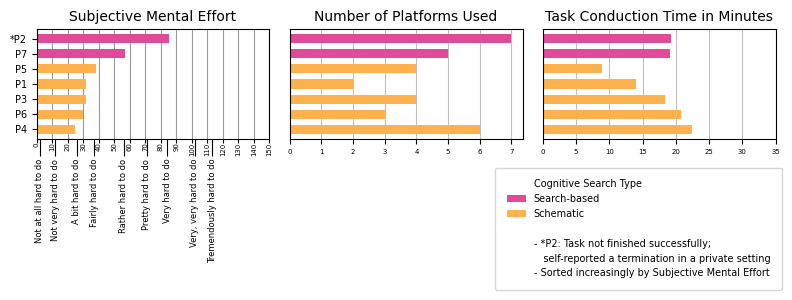

In [29]:

# --DATA PREPARATION
# Drop average: needed to only show participants as bars
df_task_effort_no_avg = df_task_effort.drop("Avg.")
# Sort table for mental effort
df_task_effort_sorted = df_task_effort_no_avg.sort_values("Mental_load", ascending=False)
# df_task_effort_sorted #uncomment to print the table
## Assign average of to individual variables; uncomment to work with mean values
'''avg_mental = df_task_effort.loc["Avg.", "Mental_load"]
avg_platforms = df_task_effort.loc["Avg.", "Platform_count"]
avg_time = df_task_effort.loc["Avg.", "Task_conduction_time_min"]'''


# -- PLOT PROPS
fig, axes = plt.subplots( # create figure canvas
    1, 3,
    figsize=(8, 3),
    sharey=True # makes all subplots share the same y-axis
)
color_map = { #applies colors to strings
    "Schematic": col_orange,
    "Search-process-based": col_pink,
}
bar_colors = df_task_effort_sorted["Cognitive_Process_Type"].map(color_map).fillna("#8E8E8E") # maps the colors to the values of the cognitive process type and fills na with grey
participants = df_task_effort_sorted.index # assigns the participant names to a variable which is needed for the y-axis labels

## -- AXIS 1: MENTAL EFFORT
ax = axes[0] #creates first subplot aka axis
ax.barh( # creates bars
    participants,
    df_task_effort_sorted["Mental_load"],
    color=bar_colors,
    height=bar_height_multi_bar_plot
    
)

# ---SMEQ labels---
difficulty_labels = { # creates a dictionairy with keys values pairs of the SMEQ annotations which is needed for the x-axis labels
     2:  "Not at all hard to do",
    12: "Not very hard to do",
    26: "A bit hard to do",
    37: "Fairly hard to do",
    56: "Rather hard to do",
    71: "Pretty hard to do",
    84: "Very hard to do",
    102: "Very, very hard to do",
    113: "Tremendously hard to do"
}
numeric_ticks = list(range(0, 151, 10)) #creates a list of integers between 0 - 150 in 10-step intervals for the x-axis labels
combined_ticks = sorted(set(numeric_ticks + list(difficulty_labels.keys()))) # combines the numeric values
ax.set_xticks(combined_ticks) # adds numeric values to x-axis
ax.set_xticklabels( # assigns numeric values (0-150 to x-axis and sets values for SMEQ annotations to be empty)
    [str(t) if t in numeric_ticks else "" for t in combined_ticks],
    rotation=90,
    fontsize=fontsize_axis_labels_task_difficulty_numeric_labels
)
ax.tick_params(axis="x", pad=-1) # moves numeric labels up
for t, label in difficulty_labels.items(): # Adds SMEQ labels
    ax.text(
        t,                     
        -0.18,                 
        label,
        ha="center",
        va="top",
        rotation=90,
        fontsize=fontsize_axis_labels_task_difficulty_text_labels,
        transform=ax.get_xaxis_transform()
    )
for tick in ax.xaxis.get_major_ticks(): # gets ticks of x-axis
    loc = tick.get_loc()  # gets tick position
    if loc in difficulty_labels: # if the position is the same as the key in the SMEQ labels dictionariy, then the tick is made longer
        tick.tick1line.set_markersize(12)
        tick.tick2line.set_markersize(12)
    else: # otherswise, for the numeric ticks, the ticks are made shorter
        tick.tick1line.set_markersize(3)
        tick.tick2line.set_markersize(3)
ax.set_title("Subjective Mental Effort", fontsize=fontsize_subplot_title) # sets title
for t in numeric_ticks: ax.axvline( t, color="gray", linestyle="-", alpha=grid_alpha, linewidth=0.8, zorder=0 ) # adds grid lines for numerical values only
ax.tick_params(axis="y", labelsize=fontsize_yaxis_labels_task_difficulty) # removes x-axis ticks


## -- AXIS 2: NUMBER OF PLATFORMS USED
ax = axes[1] # creates second subplot aka axis
ax.barh( # creates bars
    participants,
    df_task_effort_sorted["Platform_count"],
    color=bar_colors,
    height=bar_height_multi_bar_plot
)
# sets x-axis tick labels to show all integers
platform_count = df_task_effort_sorted["Platform_count"].max() # get max value of platforms
ax.set_xticks(range(0, platform_count + 1)) # set axis ticks to display all integers until the max platform count
ax.tick_params(axis="x", labelsize=fontsize_axis_labels_task_difficulty_numeric_labels) # changes font size of x-axis labels

# ax.axvline(avg_platforms, color="black", linestyle="--", linewidth=vertical_line_width) <--  uncomment to show vertical line for average, for that, you also need to uncomment the average calculation at the top of this code block
ax.set_title("Number of Platforms Used", fontsize=fontsize_subplot_title) # sets subplot title
ax.grid(axis="x", linestyle="-", alpha=grid_alpha) # sets grid lines
ax.tick_params(axis="y", which="both", left=False, labelleft=False) # removes y-axis ticks


## -- AXIS 3: TASK CONDUCTION TIME
ax = axes[2] # creates second subplot aka axis
ax.barh( # creates bars
    participants,
    df_task_effort_sorted["Task_conduction_time_min"],
    color=bar_colors,
    height=bar_height_multi_bar_plot
)
# ax.axvline(avg_time, color="black", linestyle="--", linewidth=vertical_line_width) <--uncomment to show vertical line for average, for that, you also need to uncomment the average calculation at the top of this code block
ax.set_title("Task Conduction Time in Minutes", fontsize=fontsize_subplot_title) # sets title
#ax.set_xlabel("Minutes")
ax.grid(axis="x", linestyle="-", alpha=grid_alpha) # shows grid
ax.set_xticks(range(0, 36, 5)) # creates list of ticks from 0 to 35 with 5-step intervals
ax.tick_params(axis="x", labelsize=fontsize_axis_labels_task_difficulty_numeric_labels) # changes x-axis font size
ax.tick_params(axis="y", which="both", left=False, labelleft=False) # removes y-axis ticks


# ---LEGEND
# creates patches aka legend labels
header_legend_cognitive_type = Patch(facecolor='none', edgecolor='none', label="Cognitive Search Type") 
empty_handle = Patch(facecolor='none', edgecolor='none', label="")
description_p2_a = Patch(facecolor='none', edgecolor='none', label="- *P2: Task not finished successfully;")
description_p2_b = Patch(facecolor='none', edgecolor='none', label="   self-reported a termination in a private setting")
description_bar_order = Patch(facecolor='none', edgecolor='none', label="- Sorted increasingly by Subjective Mental Effort") 
legend_elements_task_difficulty = [ # assigns patches to be legend handles aka legend labels
    header_legend_cognitive_type,
    Patch(facecolor=col_pink, label="Search-based"),
    Patch(facecolor=col_orange, label="Schematic"),
    empty_handle,
    description_p2_a,
    description_p2_b,
    description_bar_order
]
fig.legend( # assigns legend handles to legend and positions legend
    handles=legend_elements_task_difficulty,
    loc="lower right",
    bbox_to_anchor=(0.99, 0),   # x=0 (left), y=0.12 (above figtext)
    fontsize=fontsize_legend_task_difficulty,
    borderpad=1.2
)

# --- LAYOUT
for ax in axes: 
    ax.set_axisbelow(True) # sets axis to be below plots
ax.invert_yaxis()   # reverts participant order
plt.tight_layout()
plt.subplots_adjust( # adds whitespace around subplots for longer labels and the legend
    #left=0.13,
    bottom=0.52,
    #right=0.9,
    #top=0.9,
)

# -- SAVE
plt.savefig('src/figures/3_3_task_difficulty.png', bbox_inches="tight", dpi=300) # bbox makes the graph include additonal space
plt.show()


#### Playground: Additional Graphs for Correlations

In [55]:
'''plt.figure(figsize=(11, 5))

# Markers
plt.scatter(df_task_effort.index, df_task_effort["Mental_load"], marker="x", s=200, color="black")
plt.ylim(0,150)

# annotate conduction time labels on top of mental load markers
for i, row in df_task_effort.iterrows():
    plt.text(
        i, # x-position
        row["Mental_load"] + 5,   # y-position
        row["Task_conduction_time_min"], # label text with 1 decimal
        ha='center', va='bottom', fontsize=9, color='blue'
    )

#plt.yticks(x_pos, df_task_quality.index)
plt.xlabel("Time (minutes)")
plt.title("Mental Load")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig('3_1_task_solution_quality_overview.png')
plt.show()'''

'plt.figure(figsize=(11, 5))\n\n# Markers\nplt.scatter(df_task_effort.index, df_task_effort["Mental_load"], marker="x", s=200, color="black")\nplt.ylim(0,150)\n\n# annotate conduction time labels on top of mental load markers\nfor i, row in df_task_effort.iterrows():\n    plt.text(\n        i, # x-position\n        row["Mental_load"] + 5,   # y-position\n        row["Task_conduction_time_min"], # label text with 1 decimal\n        ha=\'center\', va=\'bottom\', fontsize=9, color=\'blue\'\n    )\n\n#plt.yticks(x_pos, df_task_quality.index)\nplt.xlabel("Time (minutes)")\nplt.title("Mental Load")\nplt.grid(axis="x", linestyle="--", alpha=0.5)\nplt.tight_layout()\nplt.savefig(\'3_1_task_solution_quality_overview.png\')\nplt.show()'

In [56]:
'''plt.figure(figsize=(11, 5))

# Markers
plt.scatter(df_task_effort["Platform_count"], df_task_effort["Mental_load"], marker="x", s=200, color="black")
plt.ylim(0,150)


#plt.yticks(x_pos, df_task_quality.index)
plt.xlabel("Platform Count")
plt.title("Preferred vs. Expected vs. Actual Travel Time per Participant")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig('3_1_task_solution_quality_overview.png')
plt.show()'''

'plt.figure(figsize=(11, 5))\n\n# Markers\nplt.scatter(df_task_effort["Platform_count"], df_task_effort["Mental_load"], marker="x", s=200, color="black")\nplt.ylim(0,150)\n\n\n#plt.yticks(x_pos, df_task_quality.index)\nplt.xlabel("Platform Count")\nplt.title("Preferred vs. Expected vs. Actual Travel Time per Participant")\nplt.grid(axis="x", linestyle="--", alpha=0.5)\nplt.tight_layout()\nplt.savefig(\'3_1_task_solution_quality_overview.png\')\nplt.show()'

In [57]:
'''plt.figure(figsize=(11, 5))

# Markers
plt.scatter(df_task_effort["Task_conduction_time_min"], df_task_effort["Mental_load"], marker="x", s=200, color="black")
plt.ylim(0,150)


#plt.yticks(x_pos, df_task_quality.index)
plt.xlabel("Conduction Time")
plt.title("Preferred vs. Expected vs. Actual Travel Time per Participant")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig('3_1_task_solution_quality_overview.png')
plt.show()'''

'plt.figure(figsize=(11, 5))\n\n# Markers\nplt.scatter(df_task_effort["Task_conduction_time_min"], df_task_effort["Mental_load"], marker="x", s=200, color="black")\nplt.ylim(0,150)\n\n\n#plt.yticks(x_pos, df_task_quality.index)\nplt.xlabel("Conduction Time")\nplt.title("Preferred vs. Expected vs. Actual Travel Time per Participant")\nplt.grid(axis="x", linestyle="--", alpha=0.5)\nplt.tight_layout()\nplt.savefig(\'3_1_task_solution_quality_overview.png\')\nplt.show()'

In [58]:
'''plt.figure(figsize=(11, 5))

# Markers
plt.boxplot(df_task_effort["Mental_load"])


#plt.yticks(x_pos, df_task_quality.index)
plt.xlabel("Mental Load")
plt.title("Preferred vs. Expected vs. Actual Travel Time per Participant")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig('3_1_task_solution_quality_overview.png')
plt.show()'''

'plt.figure(figsize=(11, 5))\n\n# Markers\nplt.boxplot(df_task_effort["Mental_load"])\n\n\n#plt.yticks(x_pos, df_task_quality.index)\nplt.xlabel("Mental Load")\nplt.title("Preferred vs. Expected vs. Actual Travel Time per Participant")\nplt.grid(axis="x", linestyle="--", alpha=0.5)\nplt.tight_layout()\nplt.savefig(\'3_1_task_solution_quality_overview.png\')\nplt.show()'

In [59]:
'''# sorts df for mental load
df_task_effort_sorted_mental = df_task_effort.sort_values("Mental_load")
plt.figure(figsize=(10, 6))

# Make the plot
plt.bar(df_task_effort_sorted_mental.index, df_task_effort_sorted_mental["Mental_load"], color ='blue', width = 0.5,
            edgecolor ='blue', label ='Platforms Used to Find Reachable Accommodation')

plt.bar(df_task_effort_sorted_mental.index, df_task_effort_sorted_mental["Task_conduction_time_min"], color ='red', width = 0.2,
            edgecolor ='blue', label ='Platforms Used to Find Reachable Accommodation')

plt.ylabel('Mental Load', fontsize = 12)
plt.xlabel('Participants', fontsize = 12)

plt.title('Platform Count')

plt.legend()
plt.grid(axis="y")
plt.show()'''

'# sorts df for mental load\ndf_task_effort_sorted_mental = df_task_effort.sort_values("Mental_load")\nplt.figure(figsize=(10, 6))\n\n# Make the plot\nplt.bar(df_task_effort_sorted_mental.index, df_task_effort_sorted_mental["Mental_load"], color =\'blue\', width = 0.5,\n            edgecolor =\'blue\', label =\'Platforms Used to Find Reachable Accommodation\')\n\nplt.bar(df_task_effort_sorted_mental.index, df_task_effort_sorted_mental["Task_conduction_time_min"], color =\'red\', width = 0.2,\n            edgecolor =\'blue\', label =\'Platforms Used to Find Reachable Accommodation\')\n\nplt.ylabel(\'Mental Load\', fontsize = 12)\nplt.xlabel(\'Participants\', fontsize = 12)\n\nplt.title(\'Platform Count\')\n\nplt.legend()\nplt.grid(axis="y")\nplt.show()'

In [60]:
'''# sorts df for mental load
df_task_effort_sorted_mental = df_task_effort.sort_values("Mental_load")
plt.figure(figsize=(10, 6))

# Make the plot
plt.bar(df_task_effort_sorted_mental.index, df_task_effort_sorted_mental["Mental_load"], color ='blue', width = 0.5,
            edgecolor ='blue', label ='Platforms Used to Find Reachable Accommodation')
plt.plot(
    df_task_effort_sorted_mental.index,
    df_task_effort_sorted_mental["Task_conduction_time_min"])

plt.scatter(
    df_task_effort_sorted_mental.index,
    df_task_effort_sorted_mental["Task_conduction_time_min"], marker="o"
)

plt.plot(
    df_task_effort_sorted_mental.index,
    df_task_effort_sorted_mental["Platform_count"], color="r")

plt.scatter(
    df_task_effort_sorted_mental.index,
    df_task_effort_sorted_mental["Platform_count"], marker="o", color="r"
)

plt.ylabel('Mental Load', fontsize = 12)
plt.xlabel('Participants', fontsize = 12)

plt.title('Platform Count')

plt.legend()
plt.grid(axis="y")
plt.show()'''

'# sorts df for mental load\ndf_task_effort_sorted_mental = df_task_effort.sort_values("Mental_load")\nplt.figure(figsize=(10, 6))\n\n# Make the plot\nplt.bar(df_task_effort_sorted_mental.index, df_task_effort_sorted_mental["Mental_load"], color =\'blue\', width = 0.5,\n            edgecolor =\'blue\', label =\'Platforms Used to Find Reachable Accommodation\')\nplt.plot(\n    df_task_effort_sorted_mental.index,\n    df_task_effort_sorted_mental["Task_conduction_time_min"])\n\nplt.scatter(\n    df_task_effort_sorted_mental.index,\n    df_task_effort_sorted_mental["Task_conduction_time_min"], marker="o"\n)\n\nplt.plot(\n    df_task_effort_sorted_mental.index,\n    df_task_effort_sorted_mental["Platform_count"], color="r")\n\nplt.scatter(\n    df_task_effort_sorted_mental.index,\n    df_task_effort_sorted_mental["Platform_count"], marker="o", color="r"\n)\n\nplt.ylabel(\'Mental Load\', fontsize = 12)\nplt.xlabel(\'Participants\', fontsize = 12)\n\nplt.title(\'Platform Count\')\n\nplt.lege

In [61]:
'''# Make the plot

plt.scatter(
    df_task_effort_sorted_mental["Platform_count"], 
        df_task_effort_sorted_mental["Task_conduction_time_min"], marker="o",
)


plt.ylabel('Task_conduction_time_min', fontsize = 12)
plt.xlabel('Platform_count', fontsize = 12)

plt.title('Platform Count')

plt.legend()
plt.grid(axis="y")
plt.show()'''

'# Make the plot\n\nplt.scatter(\n    df_task_effort_sorted_mental["Platform_count"], \n        df_task_effort_sorted_mental["Task_conduction_time_min"], marker="o",\n)\n\n\nplt.ylabel(\'Task_conduction_time_min\', fontsize = 12)\nplt.xlabel(\'Platform_count\', fontsize = 12)\n\nplt.title(\'Platform Count\')\n\nplt.legend()\nplt.grid(axis="y")\nplt.show()'

SMEQ - Subjective Mental Effort

In [62]:

'''plt.figure(figsize=(11, 5))
participant_codes = {p: i for i, p in enumerate(df_task_effort.index)}
df_task_effort_sorted_mental["participant_code"] = df_task_effort.index.map(participant_codes)

# Scatter: conduction time vs mental load
scatter = plt.scatter(
    df_task_effort_sorted_mental["Task_conduction_time_min"],  # X-axis
    df_task_effort_sorted_mental["Mental_load"],              # Y-axis
    c=df_task_effort_sorted_mental["participant_code"],                   # Color by participant (or assign a numeric ID)
    s=150,                                     # Marker size
    cmap='tab10',                               # Color map
    marker='o'
)

# Add participant labels on markers
for i, row in df_task_effort_sorted_mental.iterrows():
    plt.text(
        row["Task_conduction_time_min"], 
        row["Mental_load"] + 2, 
        f'P{row.name}',  # Or row["Participant"] if you have a column
        ha='center', 
        fontsize=9
    )

plt.xlabel("Task Conduction Time (minutes)")
plt.ylabel("Mental Load")
plt.title("Mental Load vs Conduction Time per Participant")
plt.grid(True, linestyle="--", alpha=0.5)
plt.colorbar(scatter, label="Participant Index")  # optional
plt.tight_layout()
plt.show()'''


'plt.figure(figsize=(11, 5))\nparticipant_codes = {p: i for i, p in enumerate(df_task_effort.index)}\ndf_task_effort_sorted_mental["participant_code"] = df_task_effort.index.map(participant_codes)\n\n# Scatter: conduction time vs mental load\nscatter = plt.scatter(\n    df_task_effort_sorted_mental["Task_conduction_time_min"],  # X-axis\n    df_task_effort_sorted_mental["Mental_load"],              # Y-axis\n    c=df_task_effort_sorted_mental["participant_code"],                   # Color by participant (or assign a numeric ID)\n    s=150,                                     # Marker size\n    cmap=\'tab10\',                               # Color map\n    marker=\'o\'\n)\n\n# Add participant labels on markers\nfor i, row in df_task_effort_sorted_mental.iterrows():\n    plt.text(\n        row["Task_conduction_time_min"], \n        row["Mental_load"] + 2, \n        f\'P{row.name}\',  # Or row["Participant"] if you have a column\n        ha=\'center\', \n        fontsize=9\n    )\n\nplt.x

In [63]:
'''plt.figure(figsize=(11, 5))

# Scatter: conduction time vs mental load
scatter = plt.scatter(
    df_task_effort_sorted_mental["Platform_count"],  # X-axis
    df_task_effort_sorted_mental["Mental_load"],              # Y-axis
    c=df_task_effort_sorted_mental["participant_code"],                   # Color by participant (or assign a numeric ID)
    s=150,                                     # Marker size
    cmap='tab10',                               # Color map
    marker='o'
)

# Add participant labels on markers
for i, row in df_task_effort_sorted_mental.iterrows():
    plt.text(
        row["Platform_count"], 
        row["Mental_load"] + 2, 
        f'P{row.name}',  # Or row["Participant"] if you have a column
        ha='center', 
        fontsize=9
    )

plt.xlabel("Platform_count")
plt.ylabel("Mental Load")
plt.title("Mental Load vs Platform_count per Participant")
plt.grid(True, linestyle="--", alpha=0.5)
plt.colorbar(scatter, label="Participant Index")  # optional
plt.tight_layout()
plt.show()'''

'plt.figure(figsize=(11, 5))\n\n# Scatter: conduction time vs mental load\nscatter = plt.scatter(\n    df_task_effort_sorted_mental["Platform_count"],  # X-axis\n    df_task_effort_sorted_mental["Mental_load"],              # Y-axis\n    c=df_task_effort_sorted_mental["participant_code"],                   # Color by participant (or assign a numeric ID)\n    s=150,                                     # Marker size\n    cmap=\'tab10\',                               # Color map\n    marker=\'o\'\n)\n\n# Add participant labels on markers\nfor i, row in df_task_effort_sorted_mental.iterrows():\n    plt.text(\n        row["Platform_count"], \n        row["Mental_load"] + 2, \n        f\'P{row.name}\',  # Or row["Participant"] if you have a column\n        ha=\'center\', \n        fontsize=9\n    )\n\nplt.xlabel("Platform_count")\nplt.ylabel("Mental Load")\nplt.title("Mental Load vs Platform_count per Participant")\nplt.grid(True, linestyle="--", alpha=0.5)\nplt.colorbar(scatter, label="Part

Platform Count

In [64]:
'''# Platform count
plt.figure(figsize=(10, 6))

# Make the plot
plt.bar(df_task_performance_trans.index, df_task_performance_trans["Platform count"], color ='blue', width = 0.5,
            edgecolor ='blue', label ='Platforms Used to Find Reachable Accommodation')

plt.ylabel('Platform Count', fontsize = 12)
plt.xlabel('Participants', fontsize = 12)

plt.title('Platform Count')

plt.legend()
plt.grid(axis="y")
plt.show()'''

'# Platform count\nplt.figure(figsize=(10, 6))\n\n# Make the plot\nplt.bar(df_task_performance_trans.index, df_task_performance_trans["Platform count"], color =\'blue\', width = 0.5,\n            edgecolor =\'blue\', label =\'Platforms Used to Find Reachable Accommodation\')\n\nplt.ylabel(\'Platform Count\', fontsize = 12)\nplt.xlabel(\'Participants\', fontsize = 12)\n\nplt.title(\'Platform Count\')\n\nplt.legend()\nplt.grid(axis="y")\nplt.show()'